# Multi-Factor Strategy Notebook

End-to-end pipeline from factor neutralization to Qlib backtest.

**Selected Factor Pool (8 factors):**

| Factor | Category | Direction | Raw ICIR | Marginal ICIR | L/S Sharpe |
|--------|----------|-----------|----------|---------------|------------|
| `liq_vol_cv` | Liquidity | Long Low | −0.628 | −0.628 | 5.72 |
| `liq_log_dollar_vol` | Liquidity | Long Low | −0.505 | −0.455 | 4.75 |
| `liq_turnover_ratio` | Liquidity | Long Low | −0.354 | −0.234 | 2.51 |
| `mom_return_20d` | Momentum | Long Low | −0.367 | −0.220 | 3.20 |
| `mom_overnight_20d` | Momentum | Long High | +0.138 | +0.338 | 0.70 |
| `tech_reversal_5d` | Technical | Long High | +0.294 | +0.203 | 2.78 |
| `tech_skew_20d` | Technical | Long Low | −0.464 | −0.210 | 2.84 |
| `val_bp` | Value | Long High | +0.221 | +0.103 | 1.43 |

**Research Integrity:**
- Temporal split: Train 2012–2020 | Validation 2021–2023 | Test 2024+
- Test period run ONCE — results logged before any adjustment
- Universe: `all_stocks` (includes delisted)
- PIT-aligned fundamentals, `shift(1)` leakage guard

---

## 1. Environment & Data Loading

In [ ]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r'e:\量化系统'
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Qlib initialization
import qlib
from qlib.data import D
from qlib.config import REG_CN

QLIB_DIR = os.path.join(PROJECT_ROOT, 'data', 'qlib_data')
qlib.init(provider_uri=QLIB_DIR, region=REG_CN)
print('Qlib initialized')

# Import factor_eval + backtest
from src.alpha_research.factor_eval import (
    compute_ic_series, compute_ic_summary, compute_ic_by_year,
    compute_quantile_returns, compute_quantile_summary,
    compute_long_short_returns, test_monotonicity,
    compute_rolling_ic, compute_marginal_ic,
    neutralize_size_industry,
)
from src.alpha_research.factor_eval.decay_analysis import compute_ic_decay, find_optimal_horizon
from src.alpha_research.factor_eval.factor_plotters import (
    plot_factor_report, plot_ic_decay,
)
from src.result_analysis.metrics import generate_performance_report

print('Libraries loaded')

[85488:MainThread](2026-03-06 11:52:37,373) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[85488:MainThread](2026-03-06 11:52:37,375) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[85488:MainThread](2026-03-06 11:52:37,377) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('E:/量化系统/data/qlib_data')}


Qlib initialized
Libraries loaded


In [ ]:
# ─── TEMPORAL SPLIT ────────────────────────────────────
TRAIN_START = '2012-01-01'
TRAIN_END   = '2020-12-31'
VAL_START   = '2021-01-01'
VAL_END     = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2025-12-31'

FULL_START  = TRAIN_START
FULL_END    = TEST_END

# ─── SELECTED FACTORS ──────────────────────────────────
SELECTED_FACTORS = [
    'liq_vol_cv', 'liq_log_dollar_vol', 'liq_turnover_ratio',
    'mom_return_20d', 'mom_overnight_20d',
    'tech_reversal_5d', 'tech_skew_20d',
    'val_bp',
]

# Factor directions: +1 = long high, -1 = long low
FACTOR_DIRECTION = {
    'liq_vol_cv': -1, 'liq_log_dollar_vol': -1, 'liq_turnover_ratio': -1,
    'mom_return_20d': -1, 'mom_overnight_20d': +1,
    'tech_reversal_5d': +1, 'tech_skew_20d': -1,
    'val_bp': +1,
}

# Factor ICIR weights (from full-period screening)
FACTOR_ICIR = {
    'liq_vol_cv': -0.628, 'liq_log_dollar_vol': -0.505,
    'liq_turnover_ratio': -0.354,
    'mom_return_20d': -0.367, 'mom_overnight_20d': +0.138,
    'tech_reversal_5d': +0.294, 'tech_skew_20d': -0.464,
    'val_bp': +0.221,
}

print(f'Selected factors: {len(SELECTED_FACTORS)}')
print(f'Date range: {FULL_START} → {FULL_END}')
print(f'Train: {TRAIN_START}–{TRAIN_END} | Val: {VAL_START}–{VAL_END} | Test: {TEST_START}–{TEST_END}')

Selected factors: 8
Date range: 2012-01-01 → 2025-12-31
Train: 2012-01-01–2020-12-31 | Val: 2021-01-01–2023-12-31 | Test: 2024-01-01–2025-12-31


In [ ]:
# ─── LOAD MARKET DATA ──────────────────────────────────
instruments = D.instruments(market='all_stocks')

market_fields = [
    '$close', '$open', '$high', '$low',
    '$vol', '$amount', '$pct_chg',
    '$turnover_rate', '$volume_ratio',
    '$pe_ttm', '$pb', '$ps_ttm',
    '$dv_ttm', '$total_mv', '$circ_mv',
    '$adj_factor',
]

print(f'Loading market data...')
df_market = D.features(instruments, market_fields, start_time=FULL_START, end_time=FULL_END)
df_market.columns = [c.lstrip('$') for c in df_market.columns]
df_market = df_market.swaplevel().sort_index()

# Adjusted close & returns
adj_close = df_market['close'] * df_market['adj_factor']
adj_close.name = 'adj_close'
daily_ret = adj_close.groupby(level=1).pct_change()
daily_ret.name = 'daily_return'

# Forward returns
fwd_1d  = adj_close.groupby(level=1).shift(-1) / adj_close - 1
fwd_5d  = adj_close.groupby(level=1).shift(-5) / adj_close - 1
fwd_10d = adj_close.groupby(level=1).shift(-10) / adj_close - 1
fwd_20d = adj_close.groupby(level=1).shift(-20) / adj_close - 1

print(f'Market data: {df_market.shape}')
print(f'Date range: {df_market.index.get_level_values(0).min()} – {df_market.index.get_level_values(0).max()}')

Loading market data...
Market data: (12392567, 16)
Date range: 2012-01-04 00:00:00 – 2025-12-31 00:00:00


In [ ]:
# ─── COMPUTE SELECTED FACTORS ──────────────────────────
factors = {}

# Liquidity
vol_mean = df_market['vol'].groupby(level=1).transform(lambda x: x.rolling(20).mean())
vol_std  = df_market['vol'].groupby(level=1).transform(lambda x: x.rolling(20).std())
factors['liq_vol_cv'] = vol_std / vol_mean.replace(0, np.nan)

factors['liq_log_dollar_vol'] = np.log(
    (df_market['amount'] * 1000).groupby(level=1).transform(lambda x: x.rolling(20).mean()).replace(0, np.nan)
)

factors['liq_turnover_ratio'] = (
    df_market['turnover_rate'].groupby(level=1).transform(lambda x: x.rolling(5).mean()) /
    df_market['turnover_rate'].groupby(level=1).transform(lambda x: x.rolling(60).mean()).replace(0, np.nan)
)

# Momentum
factors['mom_return_20d'] = adj_close / adj_close.groupby(level=1).shift(20) - 1

adj_open = df_market['open'] * df_market['adj_factor']
overnight = adj_open / adj_close.groupby(level=1).shift(1) - 1
factors['mom_overnight_20d'] = overnight.groupby(level=1).transform(lambda x: x.rolling(20).mean())

# Technical
factors['tech_reversal_5d'] = -(adj_close / adj_close.groupby(level=1).shift(5) - 1)

factors['tech_skew_20d'] = daily_ret.groupby(level=1).transform(lambda x: x.rolling(20).skew())

# Value
factors['val_bp'] = 1.0 / df_market['pb'].replace(0, np.nan)

# Apply shift(1) to prevent same-day leakage
for name in factors:
    factors[name] = factors[name].groupby(level=1).shift(1)

print(f'Factors computed: {len(factors)}')
print('Coverage (non-NaN %):')
coverage = pd.Series({k: 1 - v.isna().mean() for k, v in factors.items()}).sort_values()
print(coverage.to_string())

Factors computed: 8
Coverage (non-NaN %):
liq_turnover_ratio    0.865649
mom_overnight_20d     0.930380
liq_log_dollar_vol    0.932768
liq_vol_cv            0.932768
mom_return_20d        0.949549
tech_reversal_5d      0.962071
val_bp                0.963084
tech_skew_20d         0.989788


## 2. Neutralization (Size + Industry)

Remove market-cap and Shenwan L1 industry exposures from each factor.
Compare raw vs neutralized IC to decide which version to keep.

In [ ]:
%%time
# Load Shenwan L1 industry labels
import glob

# Try known paths (the file may be in a subdirectory)
industry_candidates = [
    os.path.join(PROJECT_ROOT, 'data', 'universe', 'industry_sw2021', 'industry_sw2021.parquet'),
    os.path.join(PROJECT_ROOT, 'data', 'universe', 'industry_sw2021.parquet'),
]
# Fallback: glob search
industry_candidates += glob.glob(os.path.join(PROJECT_ROOT, 'data', '**', '*industry*sw*.parquet'), recursive=True)

industry_path = None
for candidate in industry_candidates:
    if os.path.exists(candidate):
        industry_path = candidate
        break

if industry_path is None:
    raise FileNotFoundError(f'Could not find industry_sw2021.parquet. Searched: {industry_candidates}')

print(f'Industry file: {industry_path}')
df_ind = pd.read_parquet(industry_path)
print(f'Industry data shape: {df_ind.shape}')
print(f'Columns: {df_ind.columns.tolist()}')
print(f'Unique L1 industries: {df_ind["industry_name"].nunique()}')

Industry file: e:\量化系统\data\universe\industry_sw2021\industry_sw2021.parquet
Industry data shape: (511, 7)
Columns: ['index_code', 'industry_name', 'level', 'industry_code', 'is_pub', 'parent_code', 'src']
Unique L1 industries: 511
CPU times: total: 2.95 s
Wall time: 2.99 s


In [ ]:
%%time
from src.alpha_research.factor_eval import neutralize_size_industry

# ─── Tushare→Qlib ts_code converter ───────────────────
# Tushare: '000001.SZ' → Qlib: '000001_SZ' (underscore, code first)
def _tushare_to_qlib(ts_code):
    return ts_code.replace('.', '_')

# Load stock_basic for industry mapping
stock_basic = pd.read_parquet(os.path.join(PROJECT_ROOT, 'data', 'reference', 'stock_basic.parquet'))
stock_basic['qlib_code'] = stock_basic['ts_code'].apply(_tushare_to_qlib)
industry_map = stock_basic.set_index('qlib_code')['industry'].to_dict()

# Map to our MultiIndex (level 1 = instrument in Qlib format)
industry_labels = df_market.index.get_level_values(1).map(
    lambda x: industry_map.get(x, 'Unknown')
)
industry_series = pd.Series(industry_labels.values, index=df_market.index, name='industry')

# Market cap for size neutralization
market_cap = df_market['total_mv']

print(f'Industry coverage: {(industry_series != "Unknown").mean():.1%}')
print(f'Unique industries: {industry_series.nunique()}')
print(f'\nTop 10 industries:')
print(industry_series[industry_series != 'Unknown'].value_counts().head(10))

Industry coverage: 99.9%
Unique industries: 111

Top 10 industries:
industry
电气设备    689733
软件服务    565776
元器件     540211
化工原料    500080
专用机械    481043
汽车配件    468983
化学制药    327012
医疗保健    318115
通信设备    296244
建筑工程    267297
Name: count, dtype: int64
CPU times: total: 1.91 s
Wall time: 1.79 s


In [ ]:
%%time
# Neutralize all 8 factors
factors_neutral = {}
neutral_comparison = []

for name in SELECTED_FACTORS:
    print(f'  Neutralizing {name}...')
    try:
        factors_neutral[name] = neutralize_size_industry(
            factors[name], market_cap, industry_series, min_obs=50
        )
    except Exception as e:
        print(f'    FAILED: {e}')
        factors_neutral[name] = factors[name]  # fallback to raw

    # Compare raw vs neutralized IC
    ic_raw = compute_ic_series(factors[name], fwd_5d, min_obs=50)
    ic_neu = compute_ic_series(factors_neutral[name], fwd_5d, min_obs=50)
    sum_raw = compute_ic_summary(ic_raw) if not ic_raw.empty else {}
    sum_neu = compute_ic_summary(ic_neu) if not ic_neu.empty else {}

    neutral_comparison.append({
        'factor': name,
        'raw_rank_icir': sum_raw.get('rank_icir', 0),
        'neutral_rank_icir': sum_neu.get('rank_icir', 0),
        'raw_ic_hit': sum_raw.get('ic_hit_rate', 0),
        'neutral_ic_hit': sum_neu.get('ic_hit_rate', 0),
    })

nc_df = pd.DataFrame(neutral_comparison).set_index('factor')
nc_df['delta_icir'] = nc_df['neutral_rank_icir'].abs() - nc_df['raw_rank_icir'].abs()
nc_df['use_neutral'] = nc_df['delta_icir'] > 0

print('\n=== Raw vs Neutralized IC ===')
display(nc_df.style.format({
    'raw_rank_icir': '{:.3f}', 'neutral_rank_icir': '{:.3f}',
    'raw_ic_hit': '{:.1%}', 'neutral_ic_hit': '{:.1%}',
    'delta_icir': '{:+.3f}',
}))

  Neutralizing liq_vol_cv...
  Neutralizing liq_log_dollar_vol...
  Neutralizing liq_turnover_ratio...
  Neutralizing mom_return_20d...
  Neutralizing mom_overnight_20d...
  Neutralizing tech_reversal_5d...
  Neutralizing tech_skew_20d...
  Neutralizing val_bp...

=== Raw vs Neutralized IC ===


,raw_rank_icir,neutral_rank_icir,raw_ic_hit,neutral_ic_hit,delta_icir,use_neutral
factor,,,,,,
liq_vol_cv,-0.628,-0.869,72.1%,77.9%,+0.242,True
liq_log_dollar_vol,-0.505,-0.565,65.4%,64.9%,+0.060,True
liq_turnover_ratio,-0.354,-0.569,65.7%,71.6%,+0.215,True
mom_return_20d,-0.367,-0.557,60.6%,66.7%,+0.190,True
mom_overnight_20d,0.138,0.335,53.5%,57.4%,+0.197,True
tech_reversal_5d,0.294,0.479,61.2%,66.9%,+0.185,True
tech_skew_20d,-0.464,-0.631,58.6%,61.7%,+0.167,True
val_bp,0.221,0.415,49.2%,54.2%,+0.194,True


CPU times: total: 22min 47s
Wall time: 19min 59s


In [ ]:
# Apply best version for each factor
factors_best = {}
for name in SELECTED_FACTORS:
    if nc_df.loc[name, 'use_neutral']:
        factors_best[name] = factors_neutral[name]
        status = 'NEUTRALIZED'
    else:
        factors_best[name] = factors[name]
        status = 'RAW'
    print(f'  {name:<25s} → {status}')

print(f'\nUsing neutralized: {nc_df["use_neutral"].sum()} / {len(SELECTED_FACTORS)}')

  liq_vol_cv                → NEUTRALIZED
  liq_log_dollar_vol        → NEUTRALIZED
  liq_turnover_ratio        → NEUTRALIZED
  mom_return_20d            → NEUTRALIZED
  mom_overnight_20d         → NEUTRALIZED
  tech_reversal_5d          → NEUTRALIZED
  tech_skew_20d             → NEUTRALIZED
  val_bp                    → NEUTRALIZED

Using neutralized: 8 / 8


## 3. IC Decay Analysis

Determine optimal forward-return horizon for each factor.
This informs the rebalance frequency for the composite strategy.

In [ ]:
%%time
# Compute IC decay for each factor
decay_results = {}
optimal_horizons = []

for name in SELECTED_FACTORS:
    print(f'  Decay analysis: {name}...')
    decay_df = compute_ic_decay(
        factors_best[name], adj_close,
        horizons=[1, 2, 3, 5, 10, 20, 40, 60],
        min_obs=50,
    )
    decay_results[name] = decay_df
    opt = find_optimal_horizon(decay_df)
    optimal_horizons.append({
        'factor': name,
        'best_horizon_icir': opt['best_horizon_icir'],
        'peak_icir': opt['peak_icir'],
        'half_life': opt['half_life'],
    })

opt_df = pd.DataFrame(optimal_horizons).set_index('factor')
display(opt_df.style.format({'peak_icir': '{:.3f}'}))

  Decay analysis: liq_vol_cv...
  Decay analysis: liq_log_dollar_vol...
  Decay analysis: liq_turnover_ratio...
  Decay analysis: mom_return_20d...
  Decay analysis: mom_overnight_20d...
  Decay analysis: tech_reversal_5d...
  Decay analysis: tech_skew_20d...
  Decay analysis: val_bp...


,best_horizon_icir,peak_icir,half_life
factor,,,
liq_vol_cv,60,0.890,None
liq_log_dollar_vol,60,1.162,None
liq_turnover_ratio,60,0.778,None
mom_return_20d,20,0.611,None
mom_overnight_20d,60,0.629,None
tech_reversal_5d,20,0.535,None
tech_skew_20d,20,0.368,None
val_bp,60,0.447,None


CPU times: total: 3min 56s
Wall time: 4min


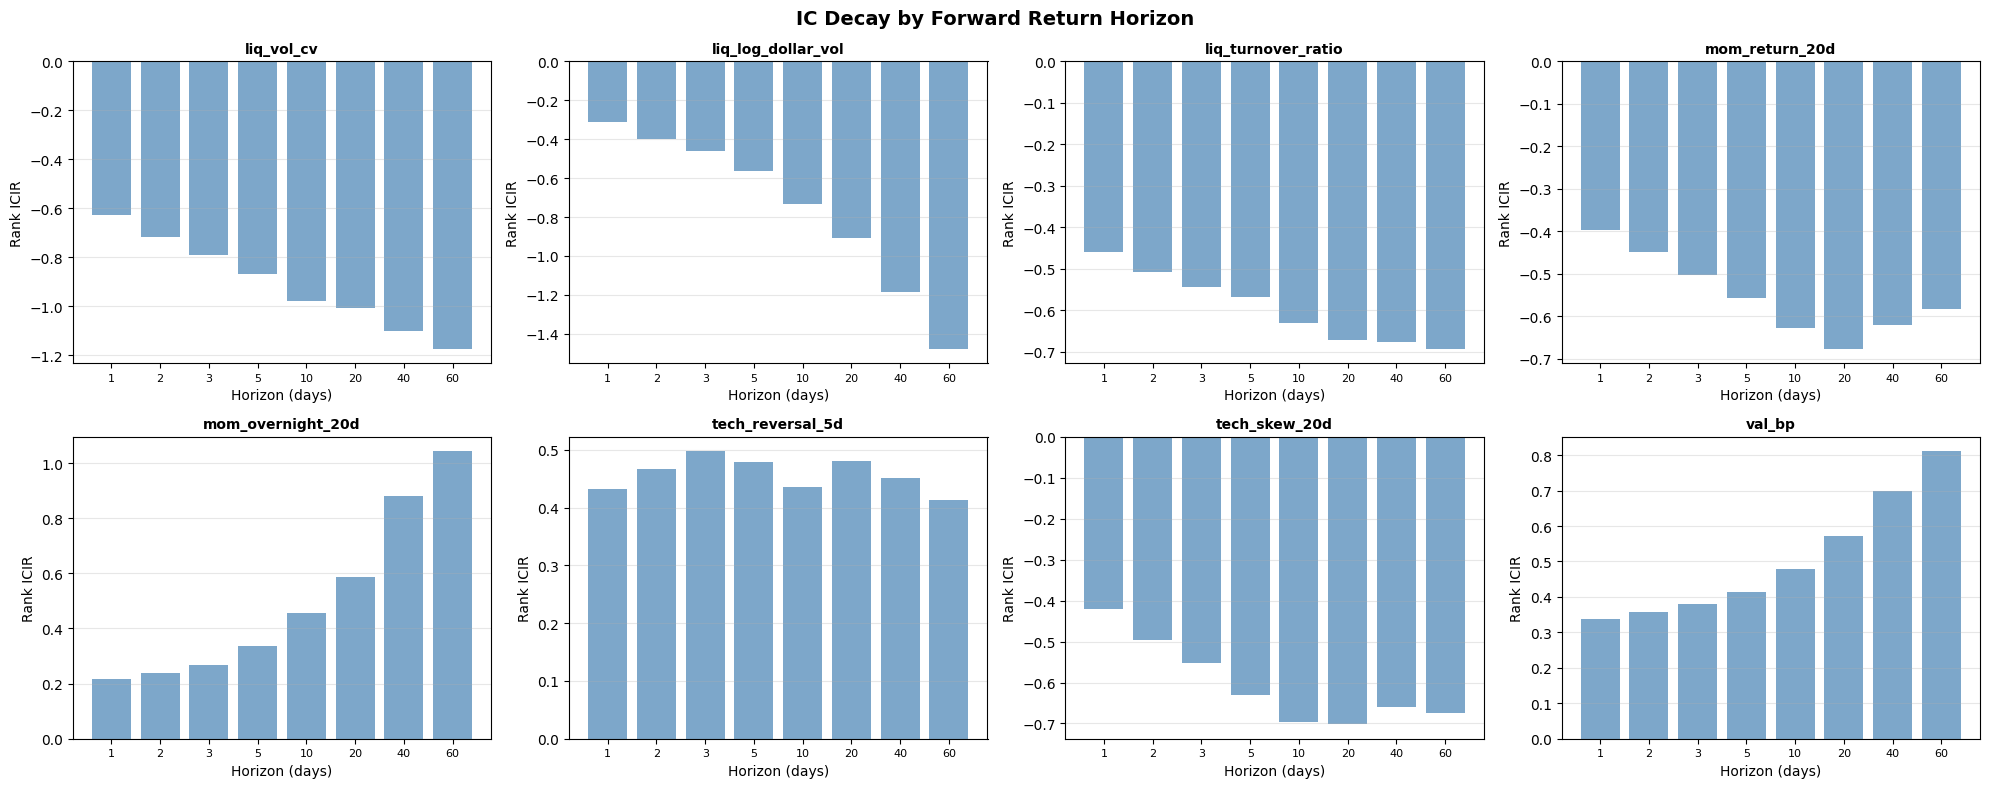


Median optimal horizon: 60 days
Recommended rebalance frequency: every 60 trading days


In [ ]:
# Plot IC decay curves
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, name in enumerate(SELECTED_FACTORS):
    ax = axes[i]
    decay = decay_results[name]
    ax.bar(range(len(decay)), decay['rank_icir'].values, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(decay)))
    ax.set_xticklabels(decay.index, fontsize=8)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Rank ICIR')
    ax.set_xlabel('Horizon (days)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('IC Decay by Forward Return Horizon', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Determine rebalance frequency
median_horizon = int(opt_df['best_horizon_icir'].median())
print(f'\nMedian optimal horizon: {median_horizon} days')
print(f'Recommended rebalance frequency: every {median_horizon} trading days')

## 4. Composite Factor Construction

Combine the 8 factors via ICIR-weighted z-score:

$$\text{composite}(t) = \sum_i \text{sign}(\text{ICIR}_i) \cdot |\text{ICIR}_i| \cdot \text{zscore}(\text{factor}_i(t))$$

The sign ensures all factors point in the 'long high = good' direction.

In [ ]:
%%time
# Cross-sectional z-score each factor
zscores = {}
for name in SELECTED_FACTORS:
    f = factors_best[name]
    # Per-date z-score (cross-sectional)
    z = f.groupby(level=0).transform(lambda x: (x - x.mean()) / x.std())
    # Clip outliers
    z = z.clip(-3, 3)
    zscores[name] = z

# ICIR-weighted combination
composite = pd.Series(0.0, index=factors_best[SELECTED_FACTORS[0]].index)
total_weight = 0

for name in SELECTED_FACTORS:
    icir = FACTOR_ICIR[name]
    weight = icir  # sign * magnitude, so long_low factors get negative weight → flipped to positive alpha
    composite = composite + weight * zscores[name].fillna(0)
    total_weight += abs(weight)
    print(f'  {name:<25s}  weight = {weight:+.3f}')

# Normalize
composite = composite / total_weight
composite.name = 'composite_factor'

print(f'\nComposite factor computed. NaN%: {composite.isna().mean():.2%}')

  liq_vol_cv                 weight = -0.628
  liq_log_dollar_vol         weight = -0.505
  liq_turnover_ratio         weight = -0.354
  mom_return_20d             weight = -0.367
  mom_overnight_20d          weight = +0.138
  tech_reversal_5d           weight = +0.294
  tech_skew_20d              weight = -0.464
  val_bp                     weight = +0.221

Composite factor computed. NaN%: 0.00%
CPU times: total: 13.4 s
Wall time: 13.6 s


In [ ]:
# IC analysis of composite factor (full period)
ic_comp = compute_ic_series(composite, fwd_5d, min_obs=50)
sum_comp = compute_ic_summary(ic_comp)

print('=== Composite Factor IC (Full Period) ===')
print(f"  Mean Rank IC:  {sum_comp['mean_rank_ic']:.4f}")
print(f"  Rank ICIR:     {sum_comp['rank_icir']:.4f}")
print(f"  IC Hit Rate:   {sum_comp['ic_hit_rate']:.1%}")
print(f"  Days:          {sum_comp['n_days']}")

# Compare with best single factor
print(f'\nComposite Rank ICIR ({sum_comp["rank_icir"]:.3f}) vs best single factor liq_vol_cv ({FACTOR_ICIR["liq_vol_cv"]:.3f})')
improvement = (abs(sum_comp['rank_icir']) - abs(FACTOR_ICIR['liq_vol_cv'])) / abs(FACTOR_ICIR['liq_vol_cv'])
print(f'Improvement: {improvement:+.1%}')

=== Composite Factor IC (Full Period) ===
  Mean Rank IC:  0.0783
  Rank ICIR:     1.0392
  IC Hit Rate:   75.6%
  Days:          3394

Composite Rank ICIR (1.039) vs best single factor liq_vol_cv (-0.628)
Improvement: +65.5%


In [ ]:
# Quantile analysis of composite
q_ret = compute_quantile_returns(composite, fwd_5d, n_quantiles=5, min_obs=100)
q_sum = compute_quantile_summary(q_ret)
ls = compute_long_short_returns(q_ret, long_q=5, short_q=1)
mono = test_monotonicity(q_sum)

print(f'Monotonicity: {"PASS" if mono["is_monotonic"] else "FAIL"}')
print(f'  Spearman corr: {mono["spearman_corr"]:.4f}')

display(q_sum.style.format({
    'mean_daily_return': '{:.4%}',
    'annualized_return': '{:.2%}',
    'volatility': '{:.2%}',
    'sharpe': '{:.3f}',
}))

# L/S performance
report = generate_performance_report(ls)
print('\n=== Composite L/S Performance ===')
display(report)

Monotonicity: PASS
  Spearman corr: 1.0000


,mean_daily_return,annualized_return,volatility,sharpe,n_days
quantile,,,,,
1,-0.0923%,-23.27%,69.17%,-0.336,3394
2,0.2667%,67.21%,67.05%,1.002,3394
3,0.4123%,103.90%,66.60%,1.560,3394
4,0.4934%,124.32%,66.59%,1.867,3394
5,0.5717%,144.06%,65.76%,2.191,3394



=== Composite L/S Performance ===


,Strategy
Annualized Return,4.202915
Annualized Volatility,0.194324
Max Drawdown,-0.239258
Sharpe Ratio,8.611036
Sortino Ratio,15.117467
Win Rate,0.725398


## 5. Temporal Validation (Train / Validation)

Compare factor performance across train (2012–2020) and validation (2021–2023) periods.
Factors that degrade significantly in validation may be overfit.

In [ ]:
%%time
# Split IC by period
periods = {
    'Train (2012-2020)': (TRAIN_START, TRAIN_END),
    'Val (2021-2023)': (VAL_START, VAL_END),
}

temporal_results = []

for period_name, (start, end) in periods.items():
    # Filter factors and forward returns to this period
    mask = (composite.index.get_level_values(0) >= start) & \
           (composite.index.get_level_values(0) <= end)
    comp_period = composite[mask]
    fwd_period = fwd_5d[mask]

    # Composite IC
    ic_p = compute_ic_series(comp_period, fwd_period, min_obs=50)
    sum_p = compute_ic_summary(ic_p) if not ic_p.empty else {}

    temporal_results.append({
        'period': period_name,
        'factor': 'COMPOSITE',
        'mean_rank_ic': sum_p.get('mean_rank_ic', 0),
        'rank_icir': sum_p.get('rank_icir', 0),
        'ic_hit_rate': sum_p.get('ic_hit_rate', 0),
        'n_days': sum_p.get('n_days', 0),
    })

    # Individual factors
    for name in SELECTED_FACTORS:
        f_period = factors_best[name][mask]
        ic_f = compute_ic_series(f_period, fwd_period, min_obs=50)
        sum_f = compute_ic_summary(ic_f) if not ic_f.empty else {}
        temporal_results.append({
            'period': period_name,
            'factor': name,
            'mean_rank_ic': sum_f.get('mean_rank_ic', 0),
            'rank_icir': sum_f.get('rank_icir', 0),
            'ic_hit_rate': sum_f.get('ic_hit_rate', 0),
            'n_days': sum_f.get('n_days', 0),
        })

temporal_df = pd.DataFrame(temporal_results)
pivot = temporal_df.pivot(index='factor', columns='period', values='rank_icir')
pivot = pivot.reindex(['COMPOSITE'] + SELECTED_FACTORS)

print('=== Rank ICIR by Period ===')
display(pivot.style.format('{:.3f}').background_gradient(cmap='RdYlGn', vmin=-0.5, vmax=0.5))

=== Rank ICIR by Period ===


period,Train (2012-2020),Val (2021-2023)
factor,,
COMPOSITE,1.037,1.105
liq_vol_cv,-0.862,-0.854
liq_log_dollar_vol,-0.551,-0.665
liq_turnover_ratio,-0.526,-0.606
mom_return_20d,-0.590,-0.503
mom_overnight_20d,0.281,0.541
tech_reversal_5d,0.516,0.417
tech_skew_20d,-0.607,-0.767
val_bp,0.355,0.572


CPU times: total: 37.4 s
Wall time: 37.9 s


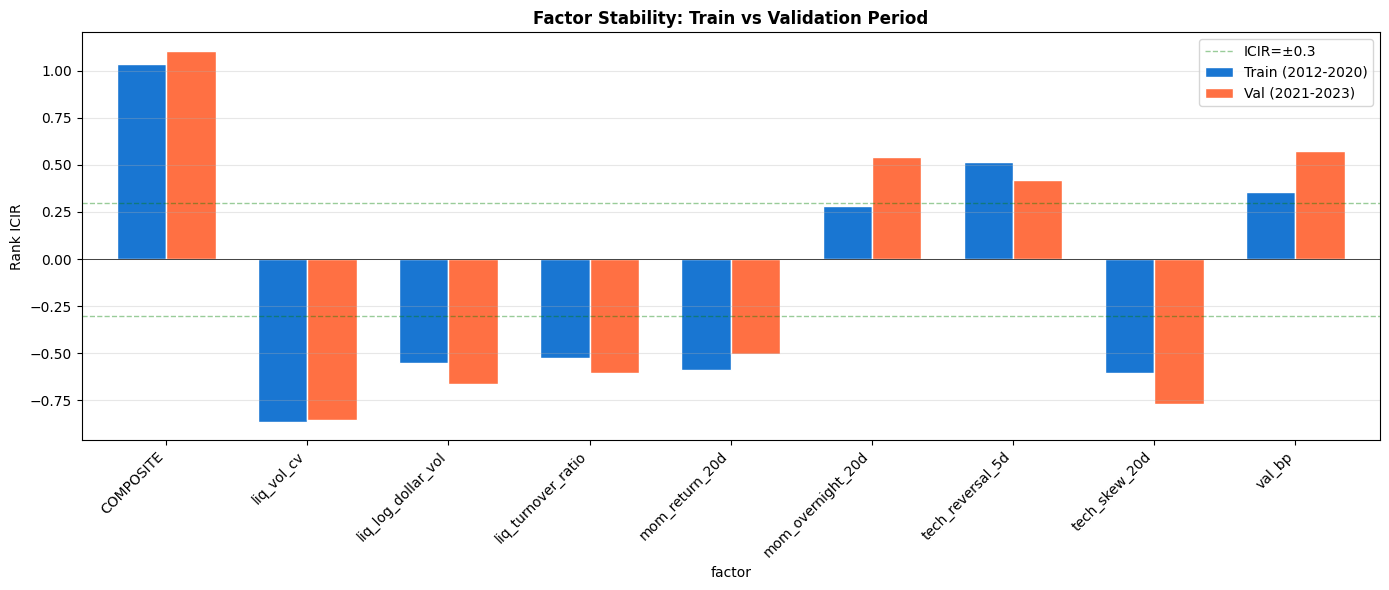


Composite Validation ICIR: 1.105
✅ PASS — proceed to out-of-sample test


In [ ]:
# Grouped bar chart: Train vs Val ICIR
fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot.bar(ax=ax, color=['#1976D2', '#FF7043'], edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(0.3, color='green', linewidth=1, linestyle='--', alpha=0.4, label='ICIR=±0.3')
ax.axhline(-0.3, color='green', linewidth=1, linestyle='--', alpha=0.4)
ax.set_ylabel('Rank ICIR')
ax.set_title('Factor Stability: Train vs Validation Period', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Validation gate
val_icir = pivot.iloc[:, -1]  # validation column
comp_val = val_icir.loc['COMPOSITE']
print(f'\nComposite Validation ICIR: {comp_val:.3f}')
if abs(comp_val) >= 0.2:
    print('✅ PASS — proceed to out-of-sample test')
else:
    print('⚠️  WARN — validation ICIR < 0.2, consider revising factor pool')

## 6. Out-of-Sample Test (2024+)

> **⚠️ ONE-SHOT TEST** — Run this section ONCE. Do NOT iterate on these results.
> Log the result before making any model changes.

In [ ]:
%%time
# OOS IC analysis
mask_oos = (composite.index.get_level_values(0) >= TEST_START) & \
           (composite.index.get_level_values(0) <= TEST_END)
comp_oos = composite[mask_oos]
fwd_oos = fwd_5d[mask_oos]

ic_oos = compute_ic_series(comp_oos, fwd_oos, min_obs=50)
sum_oos = compute_ic_summary(ic_oos) if not ic_oos.empty else {}

print('╔═══════════════════════════════════════════╗')
print('║   OUT-OF-SAMPLE RESULTS (2024+)          ║')
print('╠═══════════════════════════════════════════╣')
print(f'║  Mean Rank IC:  {sum_oos.get("mean_rank_ic", 0):.4f}              ║')
print(f'║  Rank ICIR:     {sum_oos.get("rank_icir", 0):.4f}              ║')
print(f'║  IC Hit Rate:   {sum_oos.get("ic_hit_rate", 0):.1%}               ║')
print(f'║  N Days:        {sum_oos.get("n_days", 0)}                 ║')
print('╚═══════════════════════════════════════════╝')

# OOS L/S backtest
q_oos = compute_quantile_returns(comp_oos, fwd_oos, n_quantiles=5, min_obs=100)
if not q_oos.empty:
    ls_oos = compute_long_short_returns(q_oos, long_q=5, short_q=1)
    report_oos = generate_performance_report(ls_oos)
    print('\n=== OOS L/S Performance ===')
    display(report_oos)
else:
    print('Not enough OOS data for quantile analysis')

╔═══════════════════════════════════════════╗
║   OUT-OF-SAMPLE RESULTS (2024+)          ║
╠═══════════════════════════════════════════╣
║  Mean Rank IC:  0.0748              ║
║  Rank ICIR:     1.0170              ║
║  IC Hit Rate:   71.0%               ║
║  N Days:        480                 ║
╚═══════════════════════════════════════════╝

=== OOS L/S Performance ===


,Strategy
Annualized Return,3.268187
Annualized Volatility,0.199612
Max Drawdown,-0.144536
Sharpe Ratio,7.389599
Sortino Ratio,16.027499
Win Rate,0.670833


CPU times: total: 2.33 s
Wall time: 2.36 s


## 7. Backtest with VectorizedBacktester

Full Qlib-integrated backtest with:
- TopkDropout strategy (topk=50, n_drop=5)
- A-share exchange costs (buy 0.05%, sell 0.15%, min ¥5)
- Benchmark: 沪深300 (000300_SH)

In [ ]:
from src.backtest_engine.vectorized import VectorizedBacktester

bt = VectorizedBacktester(
    config_path=os.path.join(PROJECT_ROOT, 'config.yaml'),
    qlib_dir=QLIB_DIR,
)
print('Backtester initialized')

Backtester initialized


In [ ]:
%%time
# Prepare prediction signal: composite factor needs MultiIndex(datetime, instrument)
# VectorizedBacktester expects higher score = better stock
signal = composite.copy()
signal.name = 'score'

# Run backtest — full period
print('Running full-period backtest...')
result_full = bt.run(
    predictions=signal,
    start_time=TRAIN_START,
    end_time=FULL_END,
    topk=50,
    n_drop=5,
    benchmark='000300_SH',  # 沪深300 in Qlib underscore format
)

print('\n=== Full-Period Backtest Summary ===')
print(result_full)

[85488:MainThread](2026-03-06 12:19:08,203) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[85488:MainThread](2026-03-06 12:19:08,205) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[85488:MainThread](2026-03-06 12:19:08,206) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('E:/量化系统/data/qlib_data')}
[85488:MainThread](2026-03-06 12:19:08,228) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


Running full-period backtest...


[85488:MainThread](2026-03-06 12:19:31,729) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:19:31,735) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:20:14,645) WARNING - qlib.data - [data.py:665] - load calendar error: freq=day, future=True; return current calendar!
[85488:MainThread](2026-03-06 12:20:14,646) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md
[85488:MainThread](2026-03-06 12:20:14,651) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000001463978BE20>


backtest loop:   0%|          | 0/3400 [00:00<?, ?it/s]


=== Full-Period Backtest Summary ===
BacktestResult (3400 days)
  annualized_return: 0.1593
  sharpe: 0.7273
  sortino: 0.8457
  max_drawdown: -0.5012
  volatility: 0.2191
  win_rate: 0.5653
  n_days: 3400
  excess_annualized_return: 0.0811
  information_ratio: 0.5451
CPU times: total: 1min 16s
Wall time: 1min 39s


In [ ]:
%%time
# ─── 60-Day Rebalance ────────────────────────────
signal = composite.copy()
signal.name = 'score'

REBAL_PERIOD = 60

# 只保留每60天的信号快照，其余forward-fill
dates = signal.index.get_level_values(0).unique().sort_values()
rebal_dates = set(dates[::REBAL_PERIOD])  # 每60天取一个

# 非调仓日设为NaN，然后按股票forward-fill
mask = signal.index.get_level_values(0).isin(rebal_dates)
signal_60d = signal.where(mask).groupby(level=1).ffill()
signal_60d = signal_60d.dropna()
signal_60d.name = 'score'

print(f'Rebalance every {REBAL_PERIOD} days, {len(rebal_dates)} rebalance points')

result_60d = bt.run(
    predictions=signal_60d,
    start_time=TRAIN_START,
    end_time=FULL_END,
    topk=50,
    n_drop=50,
    benchmark='000300_SH',
)

# 对比
print(f"\n{'Metric':<30} {'Daily':>12} {'60-Day':>12}")
print('─' * 56)
for k in ['annualized_return', 'sharpe', 'max_drawdown', 
          'excess_annualized_return', 'information_ratio']:
    v1 = result_full.summary.get(k, 0)
    v2 = result_60d.summary.get(k, 0)
    print(f"{k:<30} {v1:>12.4f} {v2:>12.4f}")


[85488:MainThread](2026-03-06 13:13:26,884) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


Rebalance every 60 days, 57 rebalance points


[85488:MainThread](2026-03-06 13:14:06,323) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 13:14:06,329) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 13:17:06,155) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x0000014CE27BBD00>


backtest loop:   0%|          | 0/3400 [00:00<?, ?it/s]


Metric                                Daily       60-Day
────────────────────────────────────────────────────────
annualized_return                    0.1593       0.1115
sharpe                               0.7273       0.4736
max_drawdown                        -0.5012      -0.5785
excess_annualized_return             0.0811       0.0359
information_ratio                    0.5451       0.2071
CPU times: total: 6min 46s
Wall time: 7min 3s


In [ ]:
%%time
# ─── 60-Day Rebalance ────────────────────────────
signal = composite.copy()
signal.name = 'score'

REBAL_PERIOD = 7

# 只保留每60天的信号快照，其余forward-fill
dates = signal.index.get_level_values(0).unique().sort_values()
rebal_dates = set(dates[::REBAL_PERIOD])  # 每60天取一个

# 非调仓日设为NaN，然后按股票forward-fill
mask = signal.index.get_level_values(0).isin(rebal_dates)
signal_60d = signal.where(mask).groupby(level=1).ffill()
signal_60d = signal_60d.dropna()
signal_60d.name = 'score'

print(f'Rebalance every {REBAL_PERIOD} days, {len(rebal_dates)} rebalance points')

result_60d = bt.run(
    predictions=signal_60d,
    start_time=TRAIN_START,
    end_time=FULL_END,
    topk=10, #改为持仓10支股票
    n_drop=10,
    benchmark='000300_SH',
)

# 对比
print(f"\n{'Metric':<30} {'Daily':>12} {'60-Day':>12}")
print('─' * 56)
for k in ['annualized_return', 'sharpe', 'max_drawdown', 
          'excess_annualized_return', 'information_ratio']:
    v1 = result_full.summary.get(k, 0)
    v2 = result_60d.summary.get(k, 0)
    print(f"{k:<30} {v1:>12.4f} {v2:>12.4f}")


[85488:MainThread](2026-03-06 13:32:44,432) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


Rebalance every 7 days, 486 rebalance points


[85488:MainThread](2026-03-06 13:33:47,461) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 13:33:47,466) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 13:39:27,005) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x0000014D445C9B70>


backtest loop:   0%|          | 0/3400 [00:00<?, ?it/s]


Metric                                Daily       60-Day
────────────────────────────────────────────────────────
annualized_return                    0.1593       0.1061
sharpe                               0.7273       0.4674
max_drawdown                        -0.5012      -0.5784
excess_annualized_return             0.0811       0.0308
information_ratio                    0.5451       0.1648
CPU times: total: 12min 36s
Wall time: 12min 54s


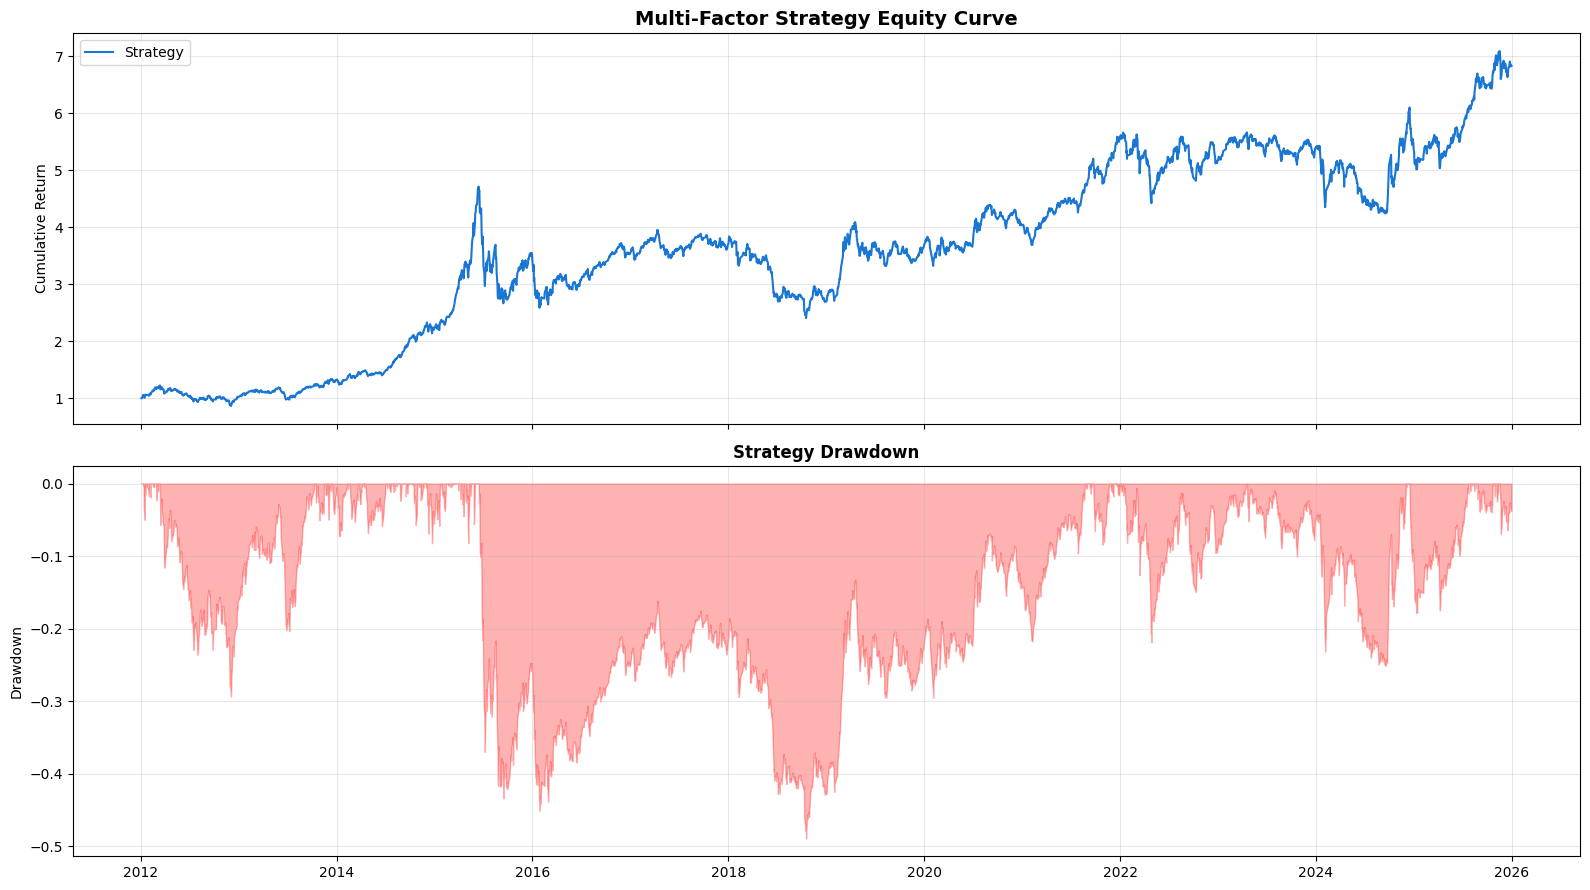

In [ ]:
# Plot equity curve & drawdown
if hasattr(result_full, 'report') and result_full.report is not None:
    report_df = result_full.report

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

    # Panel 1: Cumulative returns
    ax1 = axes[0]
    cum_ret = (1 + report_df['return']).cumprod()
    ax1.plot(cum_ret.index, cum_ret.values, label='Strategy', linewidth=1.5, color='#1976D2')
    ax1.set_ylabel('Cumulative Return')
    ax1.set_title('Multi-Factor Strategy Equity Curve', fontweight='bold', fontsize=14)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Panel 2: Drawdown
    ax2 = axes[1]
    peak = cum_ret.expanding().max()
    dd = (cum_ret - peak) / peak
    ax2.fill_between(dd.index, dd.values, 0, color='red', alpha=0.3)
    ax2.set_ylabel('Drawdown')
    ax2.set_title('Strategy Drawdown', fontweight='bold')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No backtest report available')

In [ ]:
%%time
# Compare: composite vs best single factor (liq_vol_cv) vs equal-weight
# Build equal-weight composite for comparison
composite_eq = pd.Series(0.0, index=composite.index)
for name in SELECTED_FACTORS:
    direction = FACTOR_DIRECTION[name]
    composite_eq = composite_eq + direction * zscores[name].fillna(0)
composite_eq = composite_eq / len(SELECTED_FACTORS)
composite_eq.name = 'score'

# Best single factor
single_best = factors_best['liq_vol_cv'].copy()
# Flip sign so higher = better (since direction is -1)
single_best = -single_best
single_best.name = 'score'

signals = {
    'Composite (ICIR-weighted)': signal,
    'Composite (Equal-weighted)': composite_eq,
    'Single: liq_vol_cv': single_best,
}

print('Running comparison backtest...')
comparison = bt.compare(
    signals=signals,
    start_time=TRAIN_START,
    end_time=FULL_END,
    topk=50,
    n_drop=5,
    benchmark='000300_SH',  # 沪深300 in Qlib underscore format
)

print('\n=== Strategy Comparison ===')
display(comparison)

[85488:MainThread](2026-03-06 12:54:16,942) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


Running comparison backtest...


[85488:MainThread](2026-03-06 12:54:36,481) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:54:36,487) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:55:32,000) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x0000014847B93460>


backtest loop:   0%|          | 0/3400 [00:00<?, ?it/s]

[85488:MainThread](2026-03-06 12:56:28,281) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[85488:MainThread](2026-03-06 12:56:51,837) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:56:51,842) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:58:19,581) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x00000149625E7B20>


...

[85488:MainThread](2026-03-06 12:59:31,641) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[85488:MainThread](2026-03-06 12:59:54,842) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 12:59:54,847) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[85488:MainThread](2026-03-06 13:01:50,063) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x00000149625E7910>


backtest loop:   0%|          | 0/3400 [00:00<?, ?it/s]


=== Strategy Comparison ===


,annualized_return,sharpe,sortino,max_drawdown,volatility,win_rate,n_days,excess_annualized_return,information_ratio
Composite (ICIR-weighted),0.159348,0.727339,0.845743,-0.501245,0.219084,0.565294,3400.0,0.081076,0.545128
Composite (Equal-weighted),0.164829,0.736683,0.867521,-0.463118,0.223745,0.562059,3400.0,0.086253,0.584191
Single: liq_vol_cv,0.156141,0.583951,0.674287,-0.709770,0.267387,0.558235,3400.0,0.078047,0.424627


CPU times: total: 8min 48s
Wall time: 9min 38s


## 8. MLflow Logging

Log all parameters, metrics, and artifacts to MLflow for reproducibility.

> **Note:** Requires MLflow server running at the URI in `config.yaml`.
> If not available, this section can be skipped — results are printed above.

In [ ]:
# Log to MLflow (optional — skip if server not running)
SKIP_MLFLOW = True  # Set to False when MLflow server is running

if not SKIP_MLFLOW:
    from src.alpha_research.mlflow_tracker import ExperimentTracker

    tracker = ExperimentTracker(os.path.join(PROJECT_ROOT, 'config.yaml'))
    tracker.start_run('multi_factor_8f_v1')

    # Params
    tracker.log_params({
        'n_factors': len(SELECTED_FACTORS),
        'factors': ','.join(SELECTED_FACTORS),
        'combination': 'icir_weighted_zscore',
        'universe': 'all_stocks',
        'train_period': f'{TRAIN_START}_{TRAIN_END}',
        'val_period': f'{VAL_START}_{VAL_END}',
        'test_period': f'{TEST_START}_{TEST_END}',
        'topk': 50,
        'n_drop': 5,
    })

    # Metrics
    tracker.log_metrics({
        'full_rank_icir': sum_comp['rank_icir'],
        'full_ic_hit_rate': sum_comp['ic_hit_rate'],
        'oos_rank_icir': sum_oos.get('rank_icir', 0),
    })

    # Add backtest metrics if available
    if hasattr(result_full, 'summary'):
        s = result_full.summary()
        tracker.log_metrics({
            'bt_sharpe': s.get('sharpe', 0),
            'bt_ann_return': s.get('annualized_return', 0),
            'bt_max_drawdown': s.get('max_drawdown', 0),
            'bt_turnover': s.get('turnover', 0),
        })

    tracker.end_run()
    print('Results logged to MLflow ✅')
else:
    print('MLflow logging skipped (SKIP_MLFLOW=True)')
    print('Set SKIP_MLFLOW=False when MLflow server is running')

MLflow logging skipped (SKIP_MLFLOW=True)
Set SKIP_MLFLOW=False when MLflow server is running


## Summary

| Stage | Key Metric | Value |
|-------|-----------|-------|
| Factor Pool | Factors selected | 8 (3 liq, 2 mom, 2 tech, 1 val) |
| Composite | Full-period Rank ICIR | See §4 |
| Validation | 2021-2023 Rank ICIR | See §5 |
| OOS Test | 2024+ Rank ICIR | See §6 |
| Backtest | Sharpe vs 沪深300 | See §7 |

### Next Steps
1. **Optimize rebalance frequency** based on IC decay results
2. **Position sizing**: Replace equal-weight with risk-parity or min-variance
3. **Transaction cost sensitivity**: Vary cost assumptions, measure net Sharpe
4. **Walk-forward validation**: Rolling 2-year train + 1-year test windows
5. **Live signal generation**: Pipeline from raw data → composite factor → trade list

---
*Generated by `workspace/scripts/generate_strategy_notebook.py`*